<a href="https://colab.research.google.com/github/HussainDiyab/Hussain_Diyab/blob/main/EDA_Phase1_23bds0201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA: Breast Cancer Dataset
**Phase 1 Project**
**Hussain Diyab-23BDS0201**

Exploratory Data Analysis covering dataset loading, basic stats, missing values, cleaning, transformation, and univariate, bivariate, and multivariate analyses.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
colors = {'B': 'steelblue', 'M': 'coral'}

## 1. Loading the dataset

In [2]:
url = 'https://raw.githubusercontent.com/salemprakash/EDA/main/Data/bcancer.csv'
df = pd.read_csv(url)
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Rows: 569, Columns: 33


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 2. Basic statistical analysis

In [3]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.00000,869218.00000,906024.00000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.98100,11.70000,13.37000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.71000,16.17000,18.84000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.79000,75.17000,86.24000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.50000,420.30000,551.10000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.05263,0.08637,0.09587,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.01938,0.06492,0.09263,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.00000,0.02956,0.06154,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.00000,0.02031,0.03350,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.10600,0.16190,0.17920,1.957000e-01,3.040000e-01


In [4]:
print(df['diagnosis'].value_counts())
print()
print(df['diagnosis'].value_counts(normalize=True).round(3) * 100)

diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis
B    62.7
M    37.3
Name: proportion, dtype: float64


## 3. Handling missing data

In [5]:
missing = df.isnull().sum()
print('Total missing values:', missing.sum())
print(missing[missing > 0])

Total missing values: 569
Unnamed: 32    569
dtype: int64


In [6]:
# Drop empty Unnamed: 32 column and id
df = df.drop(columns=['Unnamed: 32', 'id'], errors='ignore')
print('Shape after dropping:', df.shape)

Shape after dropping: (569, 31)


## 4. Data cleaning

In [7]:
print('Duplicate rows:', df.duplicated().sum())
print('Unique diagnosis values:', df['diagnosis'].unique())

# IQR outlier check
features = df.drop(columns=['diagnosis'])
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1
outliers = (features < Q1 - 1.5 * IQR) | (features > Q3 + 1.5 * IQR)
print('Rows with outliers:', outliers.any(axis=1).sum())

Duplicate rows: 0
Unique diagnosis values: ['M' 'B']
Rows with outliers: 171


## 5. Data transformation

In [8]:
# Encode target
df['target'] = df['diagnosis'].map({'B': 0, 'M': 1})

# Log transform skewed features
feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]
skewed = df[feature_cols].skew()[df[feature_cols].skew() > 0.75].index
df_log = df.copy()
df_log[skewed] = np.log1p(df_log[skewed])

# Scale features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[feature_cols]), columns=feature_cols)
print('Transformations complete.')

Transformations complete.


## 6. Univariate analysis (3 visualizations)

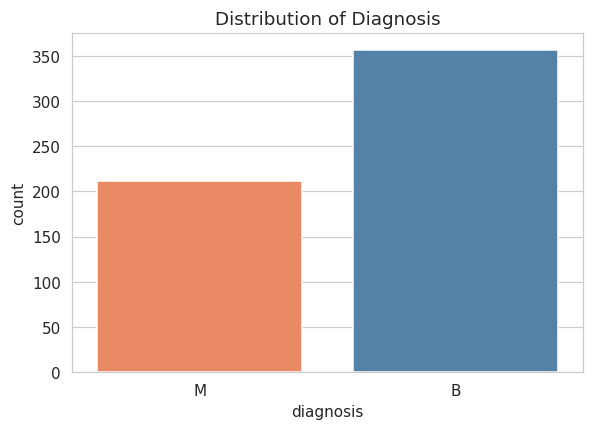

In [9]:
# Plot 1: Class balance countplot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', palette=colors)
plt.title('Distribution of Diagnosis')
plt.show()

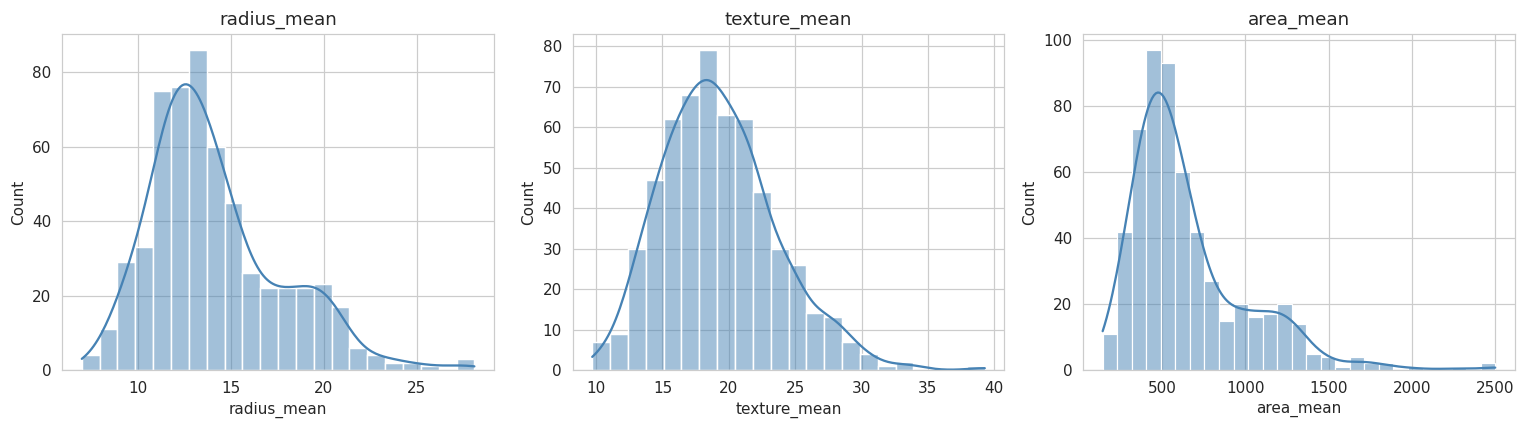

In [10]:
# Plot 2: Histograms of key features
show = ['radius_mean', 'texture_mean', 'area_mean']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, show):
    sns.histplot(df[col], kde=True, color='steelblue', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

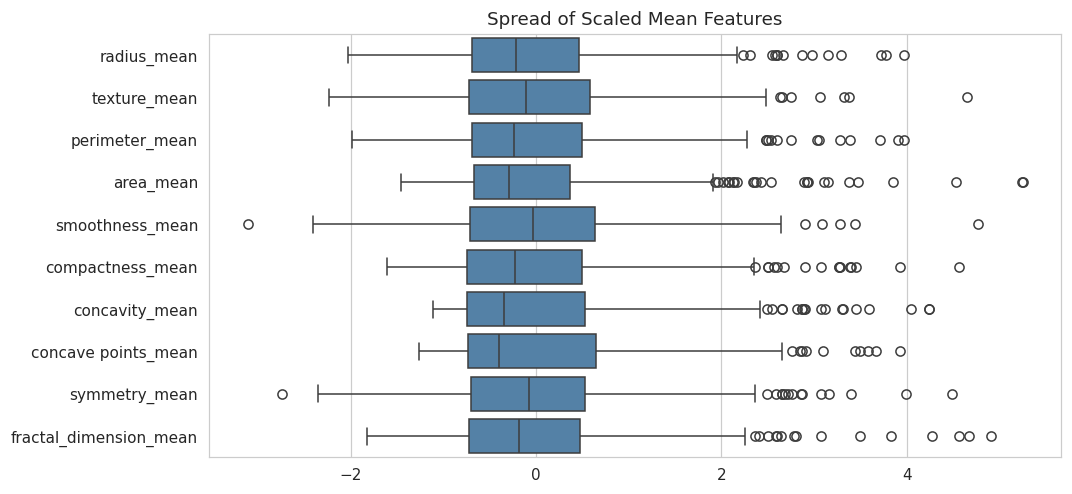

In [11]:
# Plot 3: Boxplot of scaled mean features
mean_cols = [c for c in feature_cols if c.endswith('_mean')]
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_scaled[mean_cols], orient='h', color='steelblue')
plt.title('Spread of Scaled Mean Features')
plt.show()

## 7. Bivariate analysis (3 visualizations)

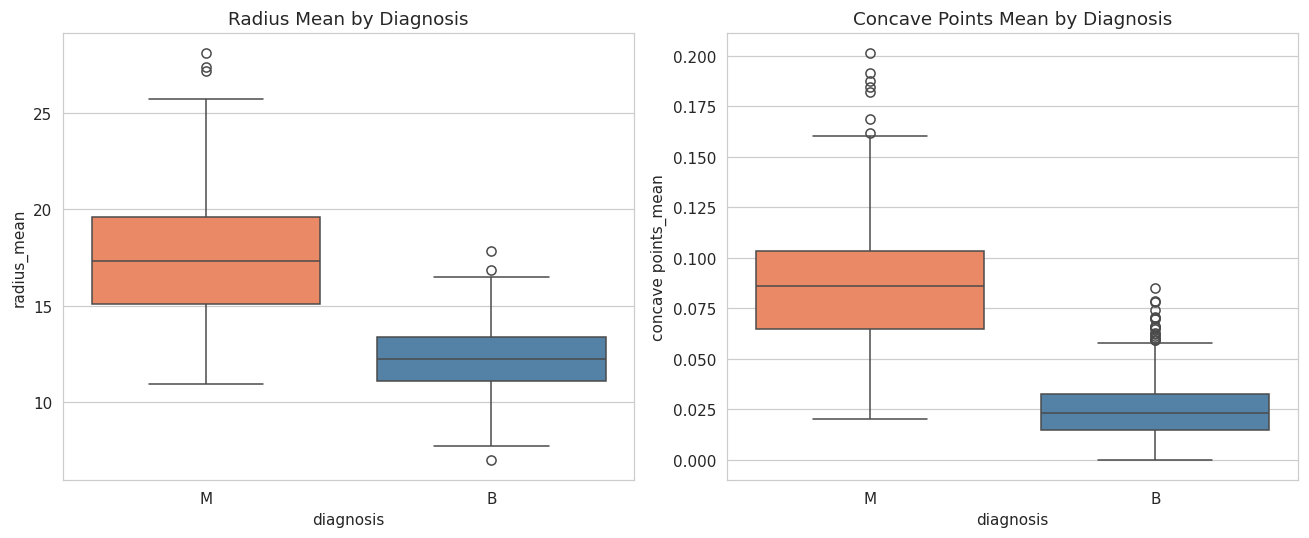

In [12]:
# Plot 1: Boxplots split by diagnosis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='diagnosis', y='radius_mean', palette=colors, ax=axes[0])
axes[0].set_title('Radius Mean by Diagnosis')
sns.boxplot(data=df, x='diagnosis', y='concave points_mean', palette=colors, ax=axes[1])
axes[1].set_title('Concave Points Mean by Diagnosis')
plt.tight_layout()
plt.show()

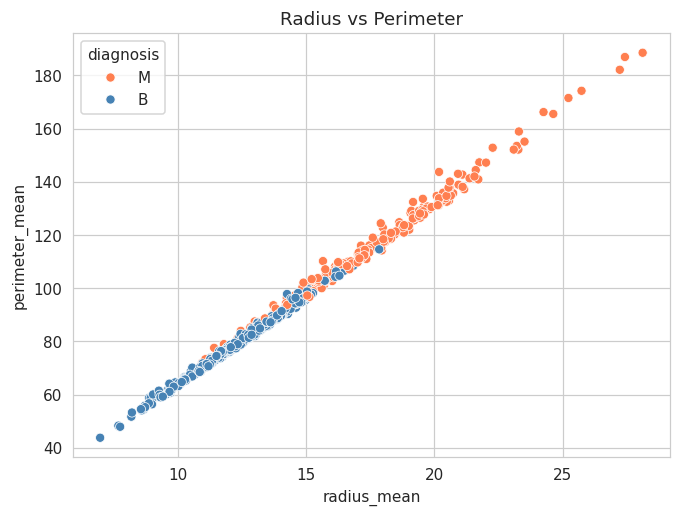

In [13]:
# Plot 2: Scatter plot of radius vs perimeter
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='radius_mean', y='perimeter_mean', hue='diagnosis', palette=colors)
plt.title('Radius vs Perimeter')
plt.show()

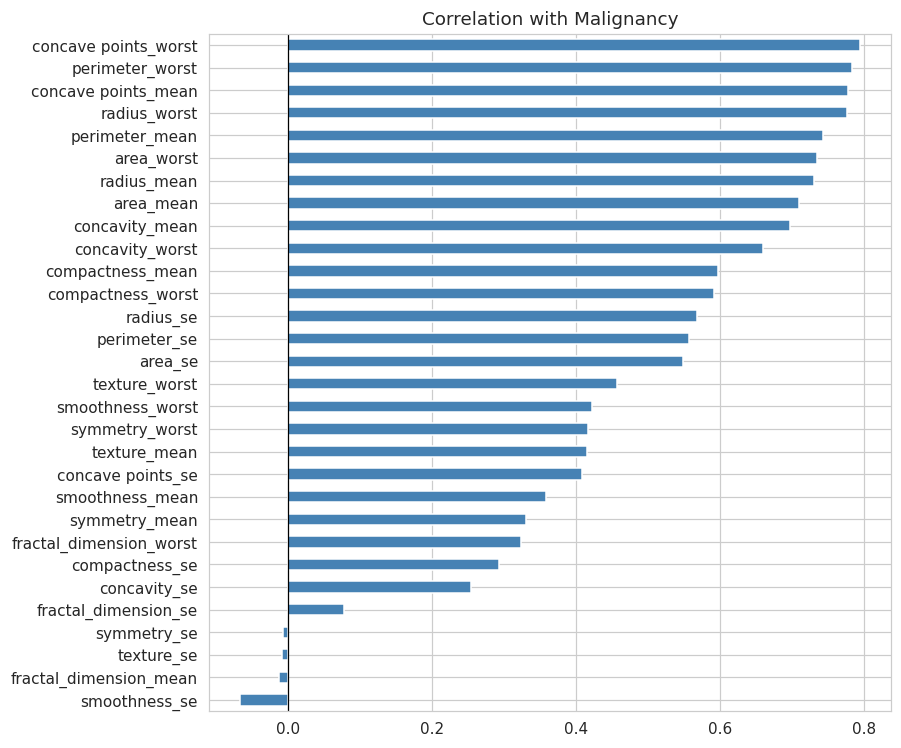

In [14]:
# Plot 3: Target correlation bar chart
target_corr = df[feature_cols].corrwith(df['target']).sort_values()
plt.figure(figsize=(8, 8))
target_corr.plot(kind='barh', color='steelblue')
plt.title('Correlation with Malignancy')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

## 8. Multivariate analysis (3 visualizations)

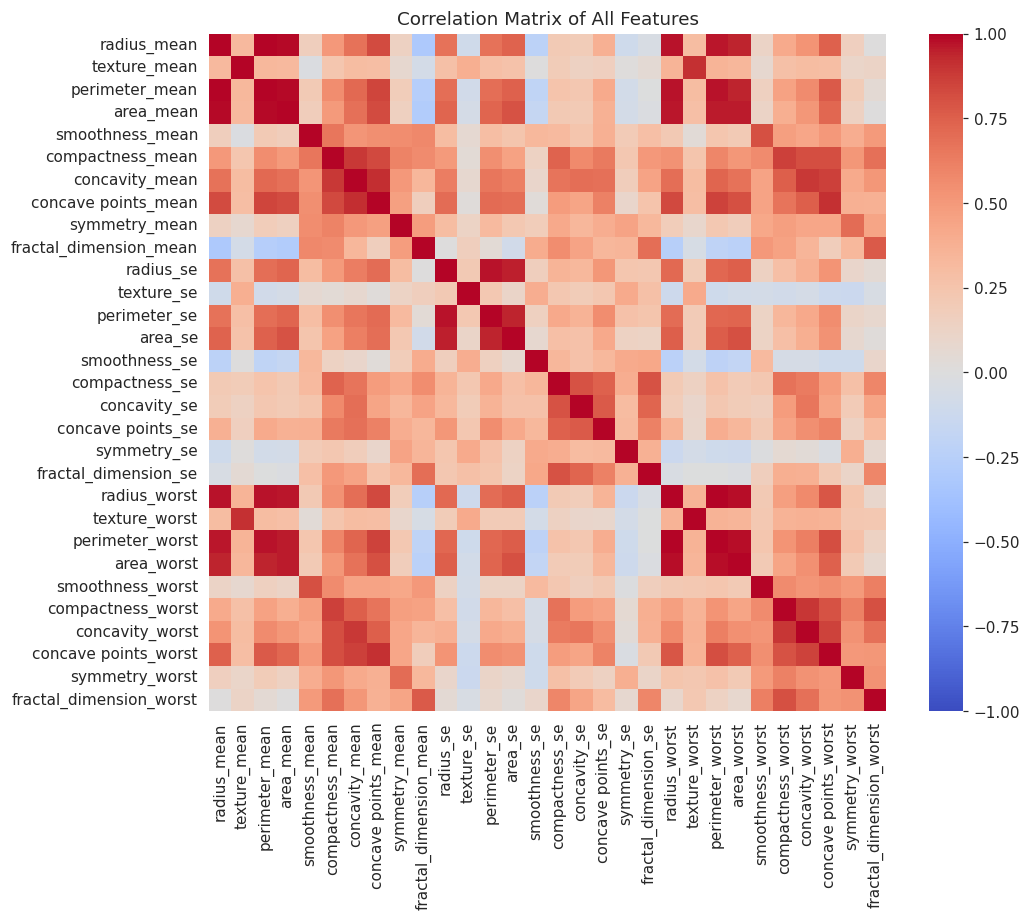

In [15]:
# Plot 1: Correlation heatmap
corr = df[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of All Features')
plt.show()

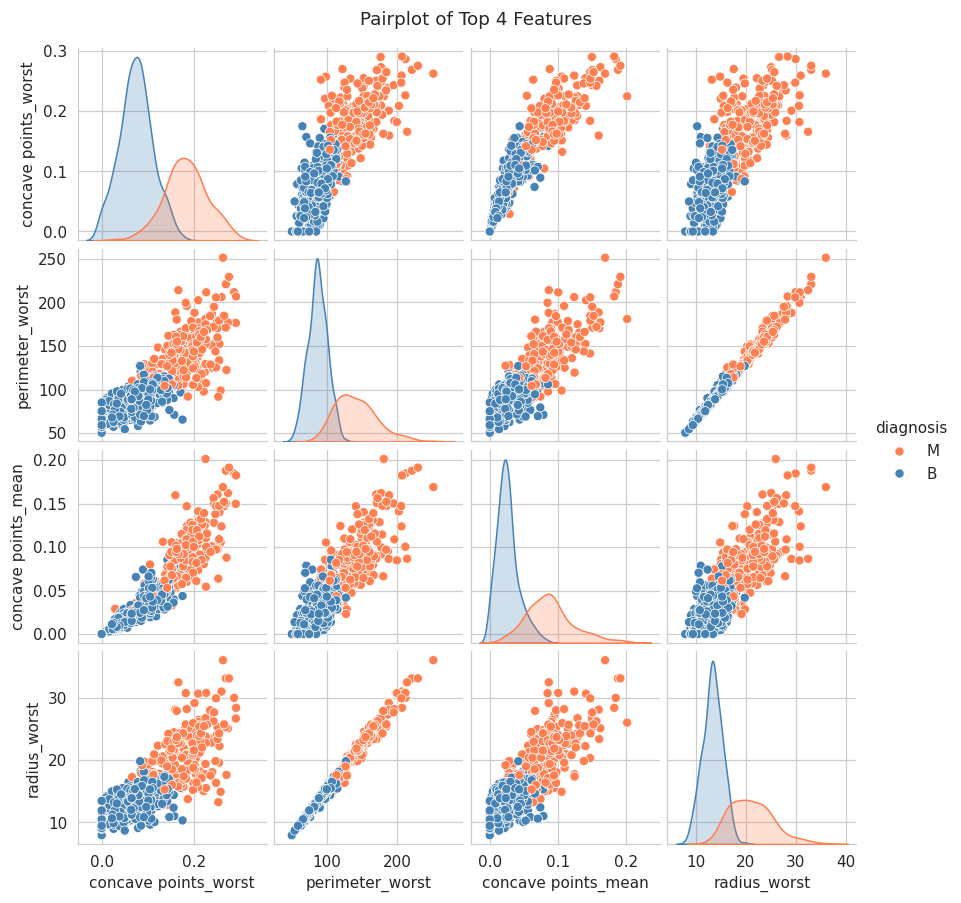

In [16]:
# Plot 2: Pairplot of top 4 features
top4 = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()
sns.pairplot(df[top4 + ['diagnosis']], hue='diagnosis', palette=colors, diag_kind='kde', height=2)
plt.suptitle('Pairplot of Top 4 Features', y=1.02)
plt.show()

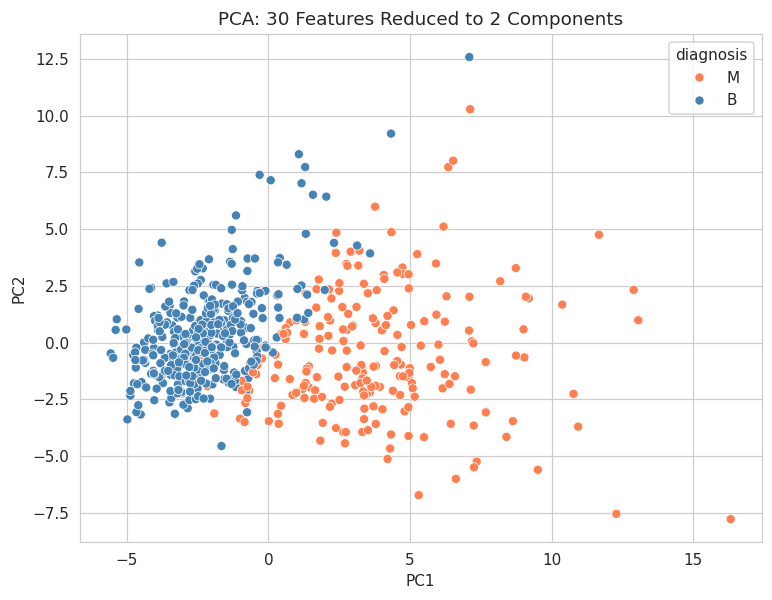

In [17]:
# Plot 3: PCA 2D Scatterplot
pca = PCA(n_components=2)
comps = pca.fit_transform(df_scaled)
pca_df = pd.DataFrame(comps, columns=['PC1', 'PC2'])
pca_df['diagnosis'] = df['diagnosis'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='diagnosis', palette=colors)
plt.title('PCA: 30 Features Reduced to 2 Components')
plt.show()

## 9. Conclusion
The exploratory data analysis is complete. The dataset is clean, missing values and IDs have been handled, and key distributions and correlations have been visualized. The univariate, bivariate, and multivariate analyses confirm distinct patterns and strong separation between benign and malignant tumor measurements.